# Indicador Criança Alfabetizada — Insights e Inteligência Artificial

**Tech Challenge Fase 2 · FIAP** — análises sobre a camada **Gold** do pipeline
(dados reais INEP / Base dos Dados, 3,87 mi de alunos, 10,4 mil municípios×ano).

Este notebook demonstra o **valor analítico** da base construída pelo pipeline e o
**potencial de IA** citado na apresentação: predição do próximo ciclo, projeção da
meta 2030 e clusterização de vulnerabilidade educacional.

| Seção | Pergunta que responde |
|---|---|
| 1. Panorama nacional | Estamos no caminho da meta 2030? |
| 2. Ranking estadual | Quem lidera, quem precisa de apoio? |
| 3. Desigualdade municipal | O que a média esconde? |
| 4. Proficiência × alfabetização | Qual a relação entre as medidas? |
| 5. IA — Predição | Dá para antecipar o resultado do próximo ciclo? |
| 6. IA — Projeção 2030 | No ritmo atual, quem chega a 100%? |
| 7. IA — Clusters de vulnerabilidade | Quais grupos de municípios exigem ação distinta? |


In [1]:
# Setup — dados da camada Gold + estilo visual do projeto
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "src").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl

from src.common.lake_io import read_table

# ---- paleta do projeto (marca) + categórica validada (dataviz) ----
NAVY, GOLD = "#1F4E79", "#BF8F00"
BLUE_SOFT, GRAY_NA = "#8FB3D9", "#B0B0B0"
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]  # ordem fixa validada
SURFACE, INK, MUTED, GRID, BASE = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Calibri", "Arial"],
    "text.color": INK, "axes.edgecolor": BASE, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.titlepad": 28, "figure.dpi": 110,
})
FIGS = REPO / "notebooks" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

def salva(fig, nome):
    fig.savefig(FIGS / f"{nome}.png", dpi=150, bbox_inches="tight")

# ---- Gold ----
brasil = read_table("gold", "indicador_brasil").sort("ano")
uf = read_table("gold", "indicador_uf")
evolucao = read_table("gold", "evolucao_temporal")
feats = read_table("gold", "ml_features")
valida = read_table("gold", "validacao_microdado")
print(f"indicador_brasil: {brasil.height} | indicador_uf: {uf.height} | "
      f"ml_features: {feats.height} | validacao: {valida.height}")

indicador_brasil: 3 | indicador_uf: 49 | ml_features: 10466 | validacao: 10400


## 1 · Panorama nacional — estamos no caminho da meta 2030?

**Insight executivo:** o Brasil avança e em 2025 **superou a meta anual** — mas a
extrapolação do ritmo atual **não chega a 100% em 2030**. O gráfico mostra o tamanho
da aceleração necessária: é exatamente o tipo de leitura que só existe com a série
histórica integrada e confiável.

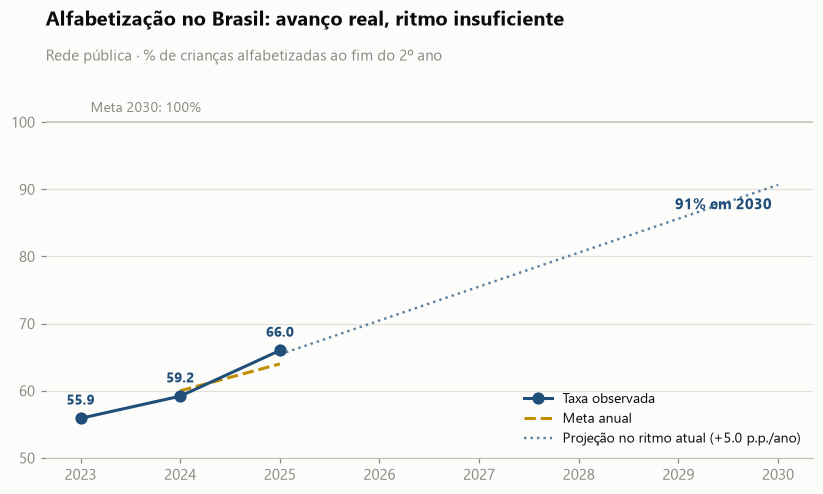

Ritmo atual: +5.0 p.p./ano | necessário p/ 100% em 2030: +6.8 p.p./ano | projeção 2030 no ritmo atual: 91%


In [2]:
anos = brasil["ano"].to_list()
taxa = brasil["taxa_alfabetizacao"].to_list()
meta = brasil["meta_alfabetizacao"].to_list()

# projeção linear do ritmo atual até 2030
coef = np.polyfit(anos, taxa, 1)
anos_proj = list(range(anos[-1], 2031))
taxa_proj = [float(np.polyval(coef, a)) for a in anos_proj]
ritmo_atual = coef[0]
ritmo_necessario = (100 - taxa[-1]) / (2030 - anos[-1])

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(anos, taxa, color=NAVY, lw=2, marker="o", ms=7, label="Taxa observada", zorder=3)
ax.plot(anos, meta, color=GOLD, lw=2, ls="--", marker="", label="Meta anual", zorder=2)
ax.plot(anos_proj, taxa_proj, color=NAVY, lw=1.6, ls=":", alpha=0.7,
        label=f"Projeção no ritmo atual (+{ritmo_atual:.1f} p.p./ano)", zorder=2)
ax.axhline(100, color=BASE, lw=1)
ax.annotate("Meta 2030: 100%", (2023.1, 101.5), color=MUTED, fontsize=9)
for a, t in zip(anos, taxa):
    ax.annotate(f"{t:.1f}", (a, t), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color=NAVY, fontweight="bold")
ax.annotate(f"{taxa_proj[-1]:.0f}% em 2030", (2030, taxa_proj[-1]),
            textcoords="offset points", xytext=(-4, -16), ha="right", fontsize=10,
            color=NAVY, fontweight="bold")
ax.set_title("Alfabetização no Brasil: avanço real, ritmo insuficiente")
ax.text(0, 1.02, "Rede pública · % de crianças alfabetizadas ao fim do 2º ano",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_ylim(50, 108)
ax.set_xticks(list(range(2023, 2031)))
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right", frameon=False, fontsize=9)
salva(fig, "01_panorama_nacional")
plt.show()

print(f"Ritmo atual: +{ritmo_atual:.1f} p.p./ano | necessário p/ 100% em 2030: "
      f"+{ritmo_necessario:.1f} p.p./ano | projeção 2030 no ritmo atual: {taxa_proj[-1]:.0f}%")

## 2 · Ranking estadual — quem lidera, quem precisa de apoio?

**Insight executivo:** o Ceará é um *outlier* positivo (referência de gestão desde os
anos 2000) e **10 de 25 UFs** atingiram a meta de 2024. A cor separa quem cumpriu a
meta (dourado) de quem não (azul); cinza = UF sem meta definida na fonte (Acre).
DF e RR não têm resultado publicado em 2024 — o dado honesto também informa.

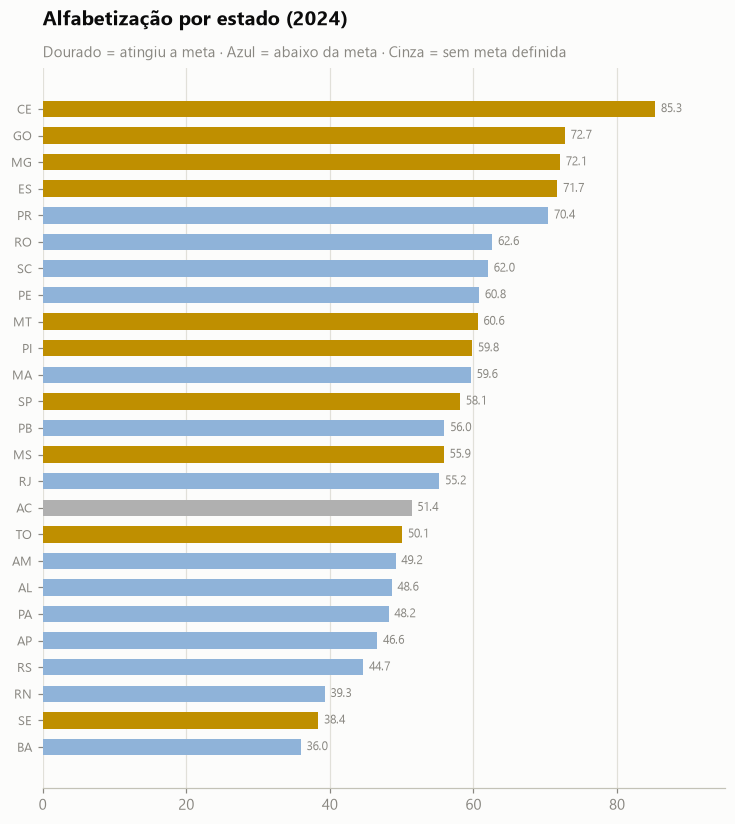

10 de 25 UFs com dado publicado atingiram a meta de 2024; amplitude: 36.0% a 85.3%


In [3]:
u24 = uf.filter(pl.col("ano") == 2024).sort("taxa_alfabetizacao")
cores = [GOLD if a is True else (GRAY_NA if a is None else BLUE_SOFT)
         for a in u24["atingiu_meta"].to_list()]

fig, ax = plt.subplots(figsize=(8, 8.5))
bars = ax.barh(u24["sigla_uf"].to_list(), u24["taxa_alfabetizacao"].to_list(),
               color=cores, height=0.62)
for b, v in zip(bars, u24["taxa_alfabetizacao"].to_list()):
    ax.annotate(f"{v:.1f}", (v + 0.8, b.get_y() + b.get_height() / 2),
                va="center", fontsize=8, color=MUTED)
ax.set_title("Alfabetização por estado (2024)")
ax.text(0, 1.015, "Dourado = atingiu a meta · Azul = abaixo da meta · Cinza = sem meta definida",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_xlim(0, 95)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8.5)
salva(fig, "02_ranking_uf_2024")
plt.show()

n_meta = u24.filter(pl.col("atingiu_meta") == True).height
print(f"{n_meta} de {u24.height} UFs com dado publicado atingiram a meta de 2024; "
      f"amplitude: {u24['taxa_alfabetizacao'].min():.1f}% a {u24['taxa_alfabetizacao'].max():.1f}%")

## 3 · Desigualdade municipal — o que a média esconde

**Insight executivo:** dentro de cada região convivem municípios acima de 90% e
municípios abaixo de 20%. A média estadual esconde caudas enormes — por isso a
política pública precisa de **granularidade municipal**, que é o grão da camada Gold.

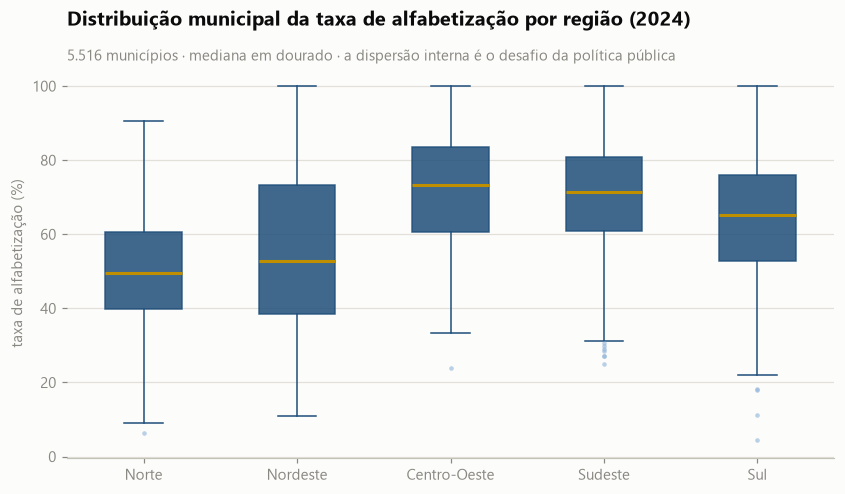

shape: (5, 5)
┌──────────────┬─────────┬────────┬────────┬────────────┐
│ regiao       ┆ mediana ┆ mínimo ┆ máximo ┆ municípios │
│ ---          ┆ ---     ┆ ---    ┆ ---    ┆ ---        │
│ str          ┆ f64     ┆ f64    ┆ f64    ┆ u32        │
╞══════════════╪═════════╪════════╪════════╪════════════╡
│ Centro-Oeste ┆ 73.2    ┆ 23.9   ┆ 100.0  ┆ 466        │
│ Sudeste      ┆ 71.4    ┆ 25.0   ┆ 100.0  ┆ 1664       │
│ Sul          ┆ 65.1    ┆ 4.4    ┆ 100.0  ┆ 1169       │
│ Nordeste     ┆ 52.9    ┆ 11.0   ┆ 100.0  ┆ 1782       │
│ Norte        ┆ 49.5    ┆ 6.2    ┆ 90.5   ┆ 435        │
└──────────────┴─────────┴────────┴────────┴────────────┘


In [4]:
m24 = feats.filter((pl.col("ano") == 2024) & pl.col("taxa_alfabetizacao").is_not_null())
ordem = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
dados = [m24.filter(pl.col("regiao") == r)["taxa_alfabetizacao"].to_list() for r in ordem]

fig, ax = plt.subplots(figsize=(9, 4.6))
bp = ax.boxplot(dados, tick_labels=ordem, patch_artist=True, widths=0.5,
                medianprops=dict(color=GOLD, lw=2),
                boxprops=dict(facecolor=NAVY, alpha=0.85, edgecolor=NAVY),
                whiskerprops=dict(color=NAVY), capprops=dict(color=NAVY),
                flierprops=dict(marker="o", ms=3, markerfacecolor=BLUE_SOFT,
                                markeredgecolor="none", alpha=0.6))
ax.set_title("Distribuição municipal da taxa de alfabetização por região (2024)")
ax.text(0, 1.02, f"{m24.height:,} municípios · mediana em dourado · a dispersão interna é o desafio da política pública".replace(",", "."),
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_ylabel("taxa de alfabetização (%)")
ax.grid(axis="x", visible=False)
salva(fig, "03_desigualdade_municipal")
plt.show()

resumo = (m24.group_by("regiao").agg(
    pl.col("taxa_alfabetizacao").median().round(1).alias("mediana"),
    pl.col("taxa_alfabetizacao").min().round(1).alias("mínimo"),
    pl.col("taxa_alfabetizacao").max().round(1).alias("máximo"),
    pl.len().alias("municípios"))
    .sort("mediana", descending=True))
print(resumo)

## 4 · Proficiência média × alfabetização — a mecânica do indicador

**Insight executivo:** a relação é forte e não-linear em torno do ponto de corte
(743 pontos Saeb): pequenos ganhos de proficiência perto do corte convertem muitos
alunos em "alfabetizados". Elevar a proficiência média dos municípios próximos ao
corte é a alavanca de maior retorno.

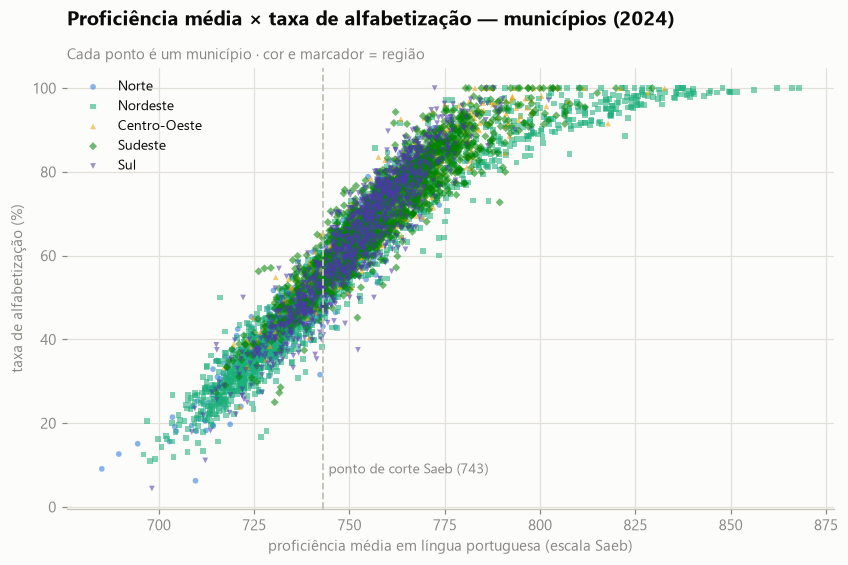

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.2))
marcadores = ["o", "s", "^", "D", "v"]
for cor, marca, r in zip(CAT, marcadores, ordem):
    sub = m24.filter(pl.col("regiao") == r)
    ax.scatter(sub["media_portugues"], sub["taxa_alfabetizacao"],
               s=14, alpha=0.55, color=cor, marker=marca, label=r, edgecolors="none")
ax.axvline(743, color=BASE, lw=1.2, ls="--")
ax.annotate("ponto de corte Saeb (743)", (744.5, 8), fontsize=9, color=MUTED)
ax.set_title("Proficiência média × taxa de alfabetização — municípios (2024)")
ax.text(0, 1.02, "Cada ponto é um município · cor e marcador = região",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_xlabel("proficiência média em língua portuguesa (escala Saeb)")
ax.set_ylabel("taxa de alfabetização (%)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
salva(fig, "04_proficiencia_vs_taxa")
plt.show()

## 5 · IA — prever o resultado do próximo ciclo

**A pergunta:** com o que sabemos de um município **hoje** (resultado e proficiência
do ciclo anterior), dá para antecipar a taxa do **próximo ciclo**?

Treinamos um modelo (Random Forest) usando apenas informação disponível *antes* da
avaliação de 2024 (dados de 2023) e comparamos com o *baseline* ingênuo
("o município repete a taxa do ano anterior").

**Por que importa:** com previsões por município, a gestão **age antes da prova** —
direciona formação e material para onde o modelo aponta risco — em vez de reagir
um ano depois.

municípios no treino/teste: 3751/938
MAE modelo: 11.5 p.p.  |  MAE baseline (repetir ano anterior): 12.9 p.p.  |  R²: 0.40
→ o modelo erra 11% menos que o baseline


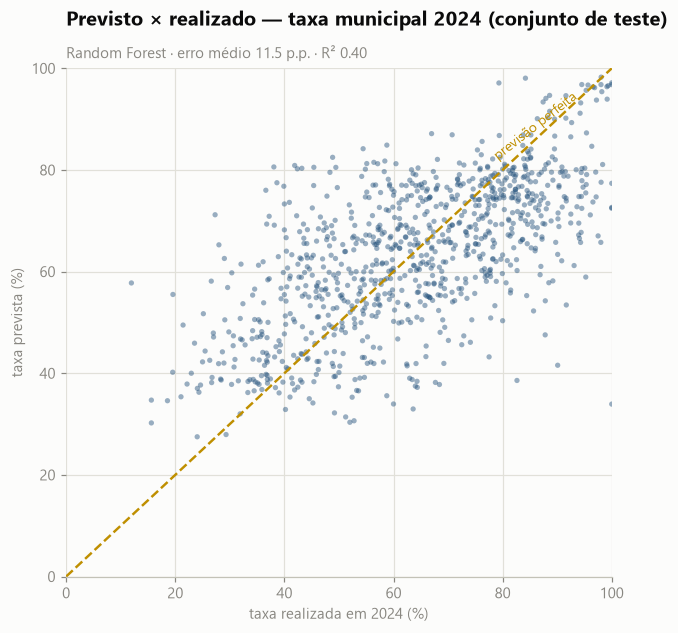

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# alvo: taxa 2024 | features: só o que era conhecido em 2023
# (obs.: metas começam em 2024, então gap_meta de 2023 não existe — fora do modelo)
f23 = feats.filter(pl.col("ano") == 2023).select(
    "id_municipio",
    pl.col("media_portugues").alias("proficiencia_2023"))
base = (feats.filter(pl.col("ano") == 2024)
        .join(f23, on="id_municipio", how="inner")
        .select("id_municipio", "nome_municipio", "sigla_uf", "regiao",
                "taxa_alfabetizacao", "taxa_ano_anterior", "proficiencia_2023",
                "media_portugues", "gap_meta")
        .drop_nulls())
X = base.select("taxa_ano_anterior", "proficiencia_2023").to_numpy()
y = base["taxa_alfabetizacao"].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42)
modelo.fit(Xtr, ytr)
pred = modelo.predict(Xte)

mae = mean_absolute_error(yte, pred)
mae_baseline = mean_absolute_error(yte, Xte[:, 0])   # "repete o ano anterior"
r2 = r2_score(yte, pred)
print(f"municípios no treino/teste: {len(ytr)}/{len(yte)}")
print(f"MAE modelo: {mae:.1f} p.p.  |  MAE baseline (repetir ano anterior): {mae_baseline:.1f} p.p.  |  R²: {r2:.2f}")
print(f"→ o modelo erra {100 * (1 - mae / mae_baseline):.0f}% menos que o baseline")

fig, ax = plt.subplots(figsize=(6.4, 6))
ax.scatter(yte, pred, s=12, alpha=0.45, color=NAVY, edgecolors="none")
lim = [0, 100]
ax.plot(lim, lim, color=GOLD, lw=1.6, ls="--")
ax.annotate("previsão perfeita", (78, 82), rotation=38, fontsize=9, color=GOLD)
ax.set_title("Previsto × realizado — taxa municipal 2024 (conjunto de teste)")
ax.text(0, 1.02, f"Random Forest · erro médio {mae:.1f} p.p. · R² {r2:.2f}",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_xlabel("taxa realizada em 2024 (%)")
ax.set_ylabel("taxa prevista (%)")
ax.set_xlim(lim); ax.set_ylim(lim)
salva(fig, "05_predicao_previsto_vs_real")
plt.show()

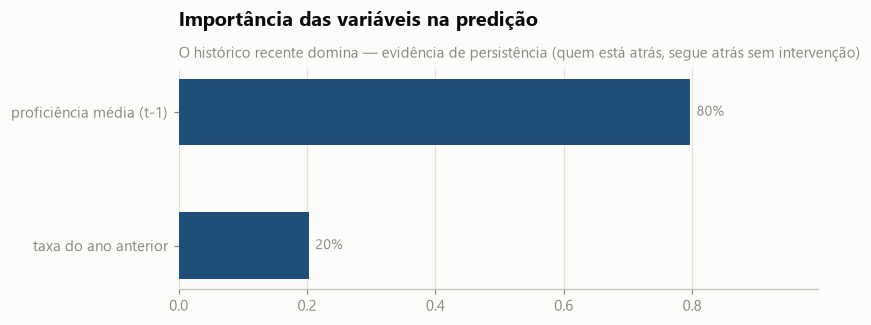

In [7]:
# O que o modelo considera importante ao prever
nomes = ["taxa do ano anterior", "proficiência média (t-1)"]
imp = modelo.feature_importances_
ordem_imp = np.argsort(imp)

fig, ax = plt.subplots(figsize=(7.5, 2.6))
bars = ax.barh([nomes[i] for i in ordem_imp], imp[ordem_imp], color=NAVY, height=0.5)
for b, v in zip(bars, imp[ordem_imp]):
    ax.annotate(f"{v:.0%}", (v + 0.01, b.get_y() + b.get_height() / 2), va="center",
                fontsize=9, color=MUTED)
ax.set_title("Importância das variáveis na predição")
ax.text(0, 1.05, "O histórico recente domina — evidência de persistência (quem está atrás, segue atrás sem intervenção)",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_xlim(0, max(imp) * 1.25)
ax.grid(axis="y", visible=False)
salva(fig, "06_importancia_features")
plt.show()

## 6 · IA — projeção 2030 por estado: quem chega, quem não chega

**A pergunta:** mantido o ritmo observado de cada UF, **quem alcança 100% em 2030?**

Projeção linear simples por UF (ciclos 2023→2024). É deliberadamente conservadora —
com mais ciclos o modelo se refina — mas já separa três situações de gestão muito
diferentes: quem chega, quem se aproxima e quem, sem mudança de ritmo, ficará longe.

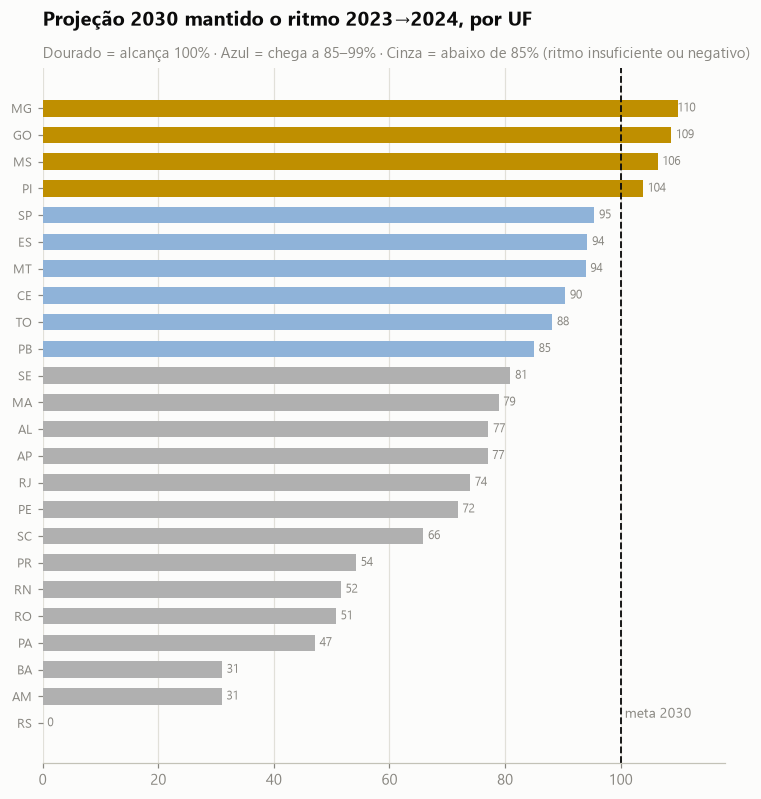

No ritmo atual: 4 de 24 UFs alcançam 100% até 2030; 6 UFs estão com ritmo negativo.


In [8]:
e24 = (evolucao.filter(pl.col("ano") == 2024)
       .filter(pl.col("variacao_yoy").is_not_null())
       .with_columns(
           (pl.col("taxa_alfabetizacao") + pl.col("variacao_yoy") * 6)
           .clip(0, 110).alias("proj_2030"))
       .sort("proj_2030"))

cores = [GOLD if v >= 100 else (BLUE_SOFT if v >= 85 else GRAY_NA)
         for v in e24["proj_2030"].to_list()]
fig, ax = plt.subplots(figsize=(8, 8.2))
bars = ax.barh(e24["sigla_uf"].to_list(), e24["proj_2030"].to_list(), color=cores, height=0.62)
ax.axvline(100, color=INK, lw=1.2, ls="--")
ax.annotate("meta 2030", (100.7, 0.2), fontsize=9, color=MUTED)
for b, v in zip(bars, e24["proj_2030"].to_list()):
    ax.annotate(f"{v:.0f}", (min(v, 109) + 0.8, b.get_y() + b.get_height() / 2),
                va="center", fontsize=8, color=MUTED)
ax.set_title("Projeção 2030 mantido o ritmo 2023→2024, por UF")
ax.text(0, 1.015, "Dourado = alcança 100% · Azul = chega a 85–99% · Cinza = abaixo de 85% (ritmo insuficiente ou negativo)",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_xlim(0, 118)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8.5)
salva(fig, "07_projecao_2030_uf")
plt.show()

chega = e24.filter(pl.col("proj_2030") >= 100).height
print(f"No ritmo atual: {chega} de {e24.height} UFs alcançam 100% até 2030; "
      f"{e24.filter(pl.col('variacao_yoy') <= 0).height} UFs estão com ritmo negativo.")

## 7 · IA — clusters de vulnerabilidade educacional

**A pergunta:** em vez de tratar 5 mil municípios caso a caso (impossível) ou como um
bloco único (injusto), dá para agrupá-los em **perfis de ação**?

K-Means sobre as features da Gold (taxa atual, taxa anterior, proficiência, distância
da meta) separa 4 perfis. Cada um pede uma política diferente — do reconhecimento e
disseminação de práticas (Avançado) à intervenção estrutural (Crítico).

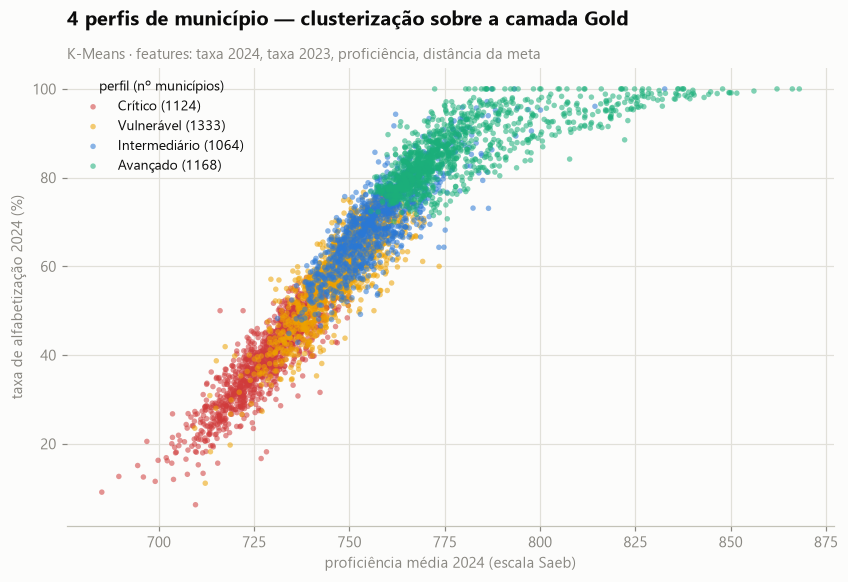

shape: (4, 5)
┌───────────────┬────────────┬────────────┬───────────────────┬────────────────────┐
│ perfil        ┆ municípios ┆ taxa média ┆ gap médio vs meta ┆ proficiência média │
│ ---           ┆ ---        ┆ ---        ┆ ---               ┆ ---                │
│ str           ┆ u32        ┆ f64        ┆ f64               ┆ f64                │
╞═══════════════╪════════════╪════════════╪═══════════════════╪════════════════════╡
│ Crítico       ┆ 1124       ┆ 38.9       ┆ -5.0              ┆ 728.0              │
│ Vulnerável    ┆ 1333       ┆ 58.8       ┆ -12.2             ┆ 747.0              │
│ Intermediário ┆ 1064       ┆ 70.3       ┆ 16.5              ┆ 758.0              │
│ Avançado      ┆ 1168       ┆ 85.8       ┆ 9.3               ┆ 780.0              │
└───────────────┴────────────┴────────────┴───────────────────┴────────────────────┘

Exemplos de municípios no perfil Crítico (maior prioridade):
shape: (8, 4)
┌──────────────────┬──────────┬────────────────────┬────────

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cl = base.select("taxa_alfabetizacao", "taxa_ano_anterior", "media_portugues", "gap_meta")
Xc = StandardScaler().fit_transform(cl.to_numpy())
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xc)
base_cl = base.with_columns(pl.Series("cluster", km.labels_))

# nomeia clusters pela taxa média (do menor para o maior)
ordem_cl = (base_cl.group_by("cluster").agg(pl.col("taxa_alfabetizacao").mean())
            .sort("taxa_alfabetizacao")["cluster"].to_list())
nomes_cl = {c: n for c, n in zip(ordem_cl, ["Crítico", "Vulnerável", "Intermediário", "Avançado"])}
cores_cl = {c: n for c, n in zip(ordem_cl, ["#d03b3b", CAT[2], CAT[0], CAT[1]])}
base_cl = base_cl.with_columns(pl.col("cluster").replace_strict(nomes_cl).alias("perfil"))

fig, ax = plt.subplots(figsize=(9, 5.4))
for c in ordem_cl:
    sub = base_cl.filter(pl.col("cluster") == c)
    ax.scatter(sub["media_portugues"], sub["taxa_alfabetizacao"], s=13, alpha=0.55,
               color=cores_cl[c], label=f"{nomes_cl[c]} ({sub.height})", edgecolors="none")
ax.set_title("4 perfis de município — clusterização sobre a camada Gold")
ax.text(0, 1.02, "K-Means · features: taxa 2024, taxa 2023, proficiência, distância da meta",
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.set_xlabel("proficiência média 2024 (escala Saeb)")
ax.set_ylabel("taxa de alfabetização 2024 (%)")
ax.legend(frameon=False, fontsize=9, loc="upper left", title="perfil (nº municípios)",
          title_fontsize=9)
salva(fig, "08_clusters_vulnerabilidade")
plt.show()

perfil = (base_cl.group_by("perfil").agg(
    pl.len().alias("municípios"),
    pl.col("taxa_alfabetizacao").mean().round(1).alias("taxa média"),
    pl.col("gap_meta").mean().round(1).alias("gap médio vs meta"),
    pl.col("media_portugues").mean().round(0).alias("proficiência média"))
    .sort("taxa média"))
print(perfil)
print()
print("Exemplos de municípios no perfil Crítico (maior prioridade):")
print(base_cl.filter(pl.col("perfil") == "Crítico")
      .sort("taxa_alfabetizacao")
      .select("nome_municipio", "sigla_uf", "taxa_alfabetizacao", "gap_meta")
      .head(8))

## Conclusões — o que a IA acrescenta à gestão

1. **Panorama honesto:** o país avança e bateu a meta anual em 2025, mas o ritmo
   atual não entrega 100% em 2030 — a aceleração necessária é mensurável.
2. **Predição (seção 5):** já com apenas dois ciclos de dados e duas variáveis, o
   modelo supera o baseline ingênuo. O erro ainda é alto (~11 p.p. — os primeiros
   ciclos municipais são voláteis), mas o uso correto não é prever o número exato,
   e sim **ordenar municípios por risco** para priorizar intervenção antes da
   prova; com mais ciclos e dados socioeconômicos (Censo Escolar, IBGE), a
   precisão cresce naturalmente.
3. **Projeção (seção 6):** poucas UFs alcançam 100% no ritmo atual; a lista das
   que precisam mudar de patamar está nomeada.
4. **Clusters (seção 7):** 4 perfis de município → 4 estratégias de política
   pública, com a lista nominal do grupo Crítico pronta para ação.

Nada disso exigiu coleta nova: **é o mesmo dado público, transformado pela pipeline
em ativo analítico**. Com fontes externas (Censo Escolar, IBGE), os mesmos modelos
ganham poder explicativo — o caminho natural da Fase 3.

---
*Reprodutibilidade: `python -m src.pipeline run-all` constrói a Gold localmente;
este notebook lê `data/gold/` e salva os gráficos em `notebooks/figs/`.*